# **Análisis de Marketing y Comunicación - Contáctos telefónicos éxitosos**


---

**Proyecto:** Equip_27 - Bank Atlas. 

**Equipo:** Analistas de Marketing y Comunicación. 

**Pregunta:** Qué relación hay entre el número de contactos realizados durante esta campaña y la tasa de éxito, y como podemos optimizar la frecuencia de contactos para maximizar los resultados de nuestras campañas de marketing?

---

**Técnica:** Análisis descriptivo(EDA) con agrupación (GROUPBY) y relaciones entre variables con cálculo de proporciones  para analizar tasa de éxito en función del número de contactos.
*Variables:* 'campaign' y 'deposit'.

---

## **1- Imports, ubicación y carga de datos**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import os
print(os.getcwd())
print(os.listdir("../../Data"))

In [ ]:
df = pd.read_parquet("../../Data/df_limpiado_260420.parquet")

## **2- Exploración de variables**

In [21]:
df[['campaign', 'deposit']].head(15)

,campaign,deposit
0,1,yes
1,1,yes
2,1,yes
3,1,yes
4,2,yes
5,2,yes
6,1,yes
7,1,yes
8,1,yes
9,3,yes


Tasa de éxito por número de contactos

## **3- Análisis principal (Relación 'campaign' vs 'deposit')**

In [22]:
success_rate = (
    df.groupby('campaign')['deposit']
    .value_counts(normalize=True)
    .unstack()
)

success_rate

deposit,no,yes
campaign,,
1,0.459819,0.540181
2,0.527965,0.472035
3,0.524981,0.475019
4,0.582345,0.417655
5,0.624324,0.375676
6,0.639216,0.360784
7,0.656934,0.343066
8,0.746032,0.253968
9,0.708333,0.291667


contactos vs probabilidad de éxito

## **4- Visualización**

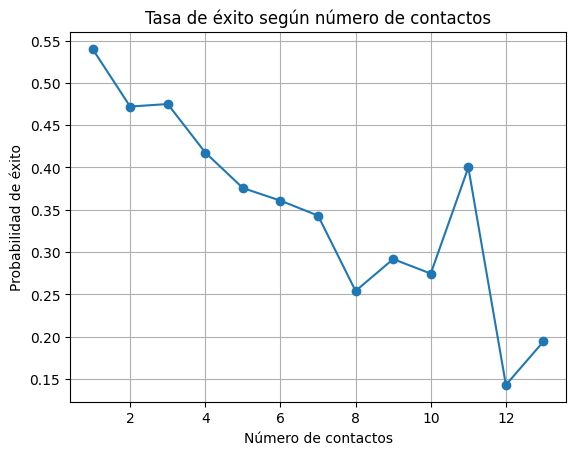

In [23]:
success_rate['yes'].plot(marker='o')
plt.title("Tasa de éxito según número de contactos")
plt.xlabel("Número de contactos")
plt.ylabel("Probabilidad de éxito")
plt.grid()
plt.show()

## **4- Agrupación de contactos**

In [24]:
def agrupar_contactos(x):
    if x <= 2:
        return "Bajo"
    elif x <= 5:
        return "Medio"
    else:
        return "Alto"

df['grupo_contacto'] = df['campaign'].apply(agrupar_contactos)

## **6- Visualización agrupada**

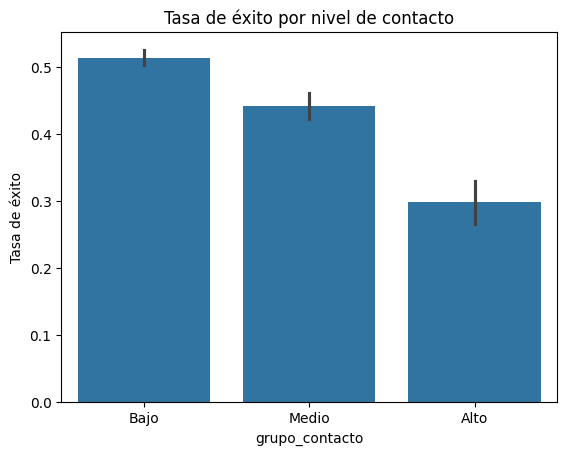

In [25]:
sns.barplot(
    data=df,
    x='grupo_contacto',
    y=(df['deposit'] == 'yes').astype(int)
)

plt.title("Tasa de éxito por nivel de contacto")
plt.ylabel("Tasa de éxito")
plt.show()

## **7- Visualización del análisis de distribución**

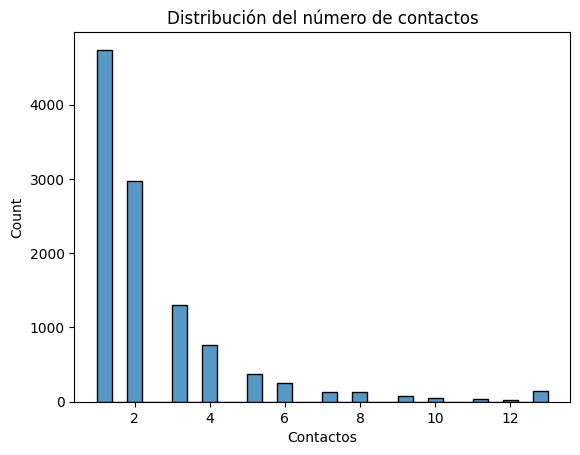

In [26]:
sns.histplot(df['campaign'], bins=30)
plt.title("Distribución del número de contactos")
plt.xlabel("Contactos")
plt.show()

## **8- Conclusiones**

- Se observa una relación negativa entre el número de contactos y la tasa de éxito.
- Los clientes con pocos contactos presentan mayor probabilidad de conversión, mientras que un exceso de contactos reduce la eficacia de la campaña, indicando un posible efecto de saturación.

## **9- Recomendaciones**

- Se recomienda optimizar la frecuencia de contacto priorizando la calidad sobre la cantidad, y evitando sobrecontactar a los clientes para maximizar la tasa de conversión.

## **10- KPI's**

In [27]:
# Variable binaria
df["deposit_bin"] = df["deposit"].map({
    "yes": 1,
    "no": 0
})

# KPI: conversión por número de contactos
conversion = (
    df.groupby("campaign")["deposit_bin"]
    .mean()
    .mul(100)
    .reset_index()
)

conversion.columns = ["num_contactos", "tasa_conversion"]

# KPI principal
best_row = conversion.loc[conversion["tasa_conversion"].idxmax()]
best_contactos = int(best_row["num_contactos"])
best_conversion = round(best_row["tasa_conversion"], 2)

# KPI global
conversion_global = round(df["deposit_bin"].mean() * 100, 2)

# OUTPUT FINAL
print(" KPI PRINCIPAL")
print(f"Conversión máxima: {best_conversion}% con {best_contactos} contactos")

print("\n KPI GLOBAL")
print(f"Conversión total de la campaña: {conversion_global}%")

 KPI PRINCIPAL
Conversión máxima: 54.02% con 1 contactos

 KPI GLOBAL
Conversión total de la campaña: 48.14%


---

## **1- Objetivo:**

### *Analizar el impacto de los diferentes tipos de contacto en la tasa de conversión de las campañas de marketing y encontrar propustas de mejora en la comunicación*

#### **Analizaremos: canal ('contact') --> conversión**

## **2- Validación de los datos**

In [ ]:
df = pd.read_csv("../../Data/df_original_260427.csv")
# Duplicados
df.duplicated().sum()

# Nulos
df.isnull().sum()

# Distribución de la variable 'contact'
df["contact"].value_counts()

contact
cellular     7928
unknown      2295
telephone     764
Name: count, dtype: Int64

Aquí validamos la calidad del dataset antes de entrar en el análisis y observamos que dentro de la nueva variable que incorporamos para el análisis 'contact' hay 2295 datos dentro de la categoría 'unknown' lo que puede introducir sesgos en la interpretación por relevancia en la cantidad de datos faltantes.

## **3- Análisis en 3 capas**

Capa 1 → impacto directo
Capa 2 → contexto (contact + campaign)
Capa 3 → regresión (validación)

### **Capa 1- Impacto Directo del Canal**

### ***Objetivo:*** que canal convierte mejor?

In [29]:
# Target binario
df["deposit_bin"] = df["deposit"].map({"yes": 1, "no": 0})

# Dataset de análisis (limpio mínimo)
df_analisis = df.dropna(subset=["contact", "deposit_bin", "campaign"])

# Conversión por canal
conversion_contact = (
    df_analisis
    .groupby("contact")["deposit_bin"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={
        "mean": "conversion_rate",
        "count": "volume"
    })
)

# En porcentaje
conversion_contact["conversion_rate"] *= 100

conversion_contact

,contact,conversion_rate,volume
0,cellular,55.108476,7928
1,telephone,51.047120,764
2,unknown,23.093682,2295


El canal móvil presenta una mayor tasa de conversión que el telefónico.
Sin embargo, existe un fuerte desbalance en el volumen de contactos y una categoría ‘unknown’, lo que puede influir en la interpretación

### **Capa 2- Contexto (donde está el valor)**

### ***Objetivo:*** Responder si el canal depende del número de contactos?

### **Preparación**

In [30]:
# Agrupar número de contactos
df_analisis["campaign_group"] = pd.cut(
    df_analisis["campaign"],
    bins=[0,1,3,6,100],
    labels=["1", "2-3", "4-6", "7+"]
)

### **Análisis**

In [31]:
conversion_context = (
    df_analisis
    .groupby(["contact", "campaign_group"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_context["deposit_bin"] *= 100
conversion_context

C:\Users\GCCM_\AppData\Local\Temp\ipykernel_36516\1474113335.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["contact", "campaign_group"])["deposit_bin"]


,contact,campaign_group,deposit_bin
0,cellular,1,61.220416
1,cellular,2-3,54.196487
2,cellular,4-6,45.197169
3,cellular,7+,30.446927
4,telephone,1,64.604811
5,telephone,2-3,48.561151
6,telephone,4-6,34.126984
7,telephone,7+,34.782609
8,unknown,1,23.966066
9,unknown,2-3,23.773173


### **Visualización**

In [32]:
fig = px.line(
    conversion_context,
    x="campaign_group",
    y="deposit_bin",
    color="contact",
    markers=True,
    title="Tasa de conversión por canal y número de contactos",
    labels={
        "campaign_group": "Número de contactos",
        "deposit_bin": "Tasa de conversión (%)",
        "contact": "Tipo de contacto"
    }
)

fig.update_layout(
    yaxis_ticksuffix="%",
    template="plotly_white"
)

fig.show()

El impacto del canal no es uniforme.
Observamos que el canal móvil es más eficaz en los primeros contactos, pero su rendimiento disminuye a medida que aumenta el número de intentos, evidenciando un efecto de saturación

### **Capa 3- Regresión logística (validación)**

### ***Objetivo:*** Validar el análisis controlando variables

In [33]:
# Variables
X = df[["contact", "campaign", "age"]]
y = df["deposit_bin"]

categorical = ["contact"]
numeric = ["campaign", "age"]

# Pipeline categórico
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Pipeline numérico
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesador
preprocessor = ColumnTransformer([
    ("cat", categorical_pipeline, categorical),
    ("num", numeric_pipeline, numeric)
])

# Modelo
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Entrenamiento
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [34]:
# Evaluación básica
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.62147406733394

In [35]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
}).sort_values(by="coef", ascending=False)

coef_df

,feature,coef
3,num__age,0.057461
0,cat__contact_telephone,-0.147891
2,num__campaign,-0.301908
1,cat__contact_unknown,-1.374004


Se ha construido un modelo de regresión logística como validación del análisis, incorporando variables de control como el número de contactos previos (campaign) y la edad (age). Esto permite aislar el efecto del tipo de contacto sobre la conversión, evitando atribuir las diferencias observadas únicamente al canal cuando pueden estar influenciadas por la intensidad de interacción o el perfil del cliente.

Los resultados confirman que tanto el tipo de contacto como el número de contactos influyen en la probabilidad de conversión, reforzando los patrones observados en el análisis descriptivo.

---

#### **Además de confirmar los resultados que ya veniamos observando decidimos de incorporar nuevas variables de control que nos ayuden a profuncdizar y entender que pueden estar impactando en que se contacte por móvil o por teléfono fijo**

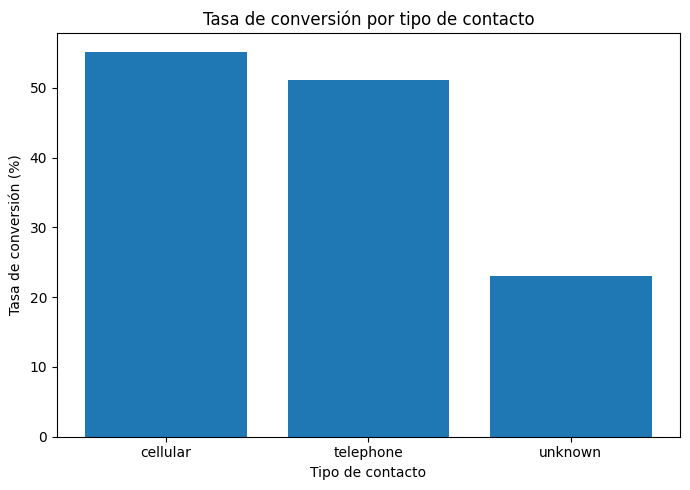

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(
    conversion_contact["contact"],
    conversion_contact["conversion_rate"]
)

plt.title("Tasa de conversión por tipo de contacto")
plt.xlabel("Tipo de contacto")
plt.ylabel("Tasa de conversión (%)")
plt.tight_layout()
plt.show()

---

## **Barras Comparativo**

C:\Users\GCCM_\AppData\Local\Temp\ipykernel_36516\3432428826.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["contact", "campaign_group"])["deposit_bin"]


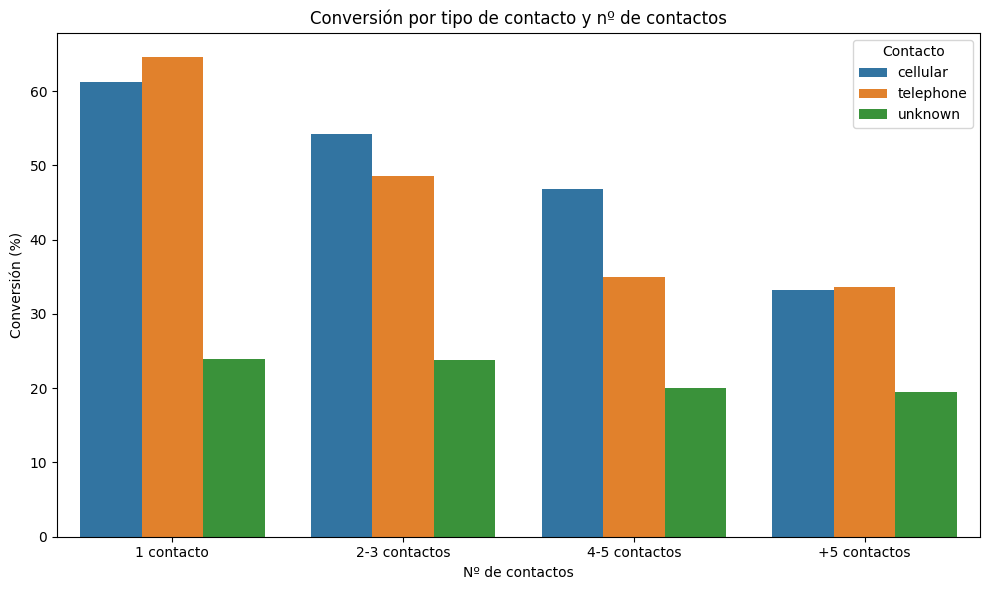

In [40]:
conversion = (
    df.groupby(["contact", "campaign_group"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion["conversion_rate"] = conversion["deposit_bin"] * 100

plt.figure(figsize=(10, 6))

sns.barplot(
    data=conversion,
    x="campaign_group",
    y="conversion_rate",
    hue="contact"
)

plt.title("Conversión por tipo de contacto y nº de contactos")
plt.xlabel("Nº de contactos")
plt.ylabel("Conversión (%)")
plt.legend(title="Contacto")
plt.tight_layout()
plt.show()

In [42]:
df.groupby(["contact", "age_group"])["deposit_bin"].mean()

C:\Users\GCCM_\AppData\Local\Temp\ipykernel_36516\2867606941.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["contact", "age_group"])["deposit_bin"].mean()


contact    age_group
cellular   <30          0.646254
           30-45        0.501778
           46-60        0.513300
           >60          0.843091
telephone  <30          0.494118
           30-45        0.397321
           46-60        0.427007
           >60          0.784530
unknown    <30          0.302198
           30-45        0.225318
           46-60        0.203869
           >60          0.000000
Name: deposit_bin, dtype: float64

---


## **Agregamos 'age'**

### **Código para integrar 'age'**

#### **Grupos de edad**

In [43]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["<30", "30-45", "46-60", ">60"]
)

#### **Conversión segmentada**

In [44]:
conversion_age = (
    df.groupby(["age_group", "contact"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_age["conversion_rate"] = conversion_age["deposit_bin"] * 100

C:\Users\GCCM_\AppData\Local\Temp\ipykernel_36516\2391714156.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "contact"])["deposit_bin"]


## **Gráfico de conversión por edad y tipo de contacto**

#### **Comparar canal dentro de cada grupo de edad**

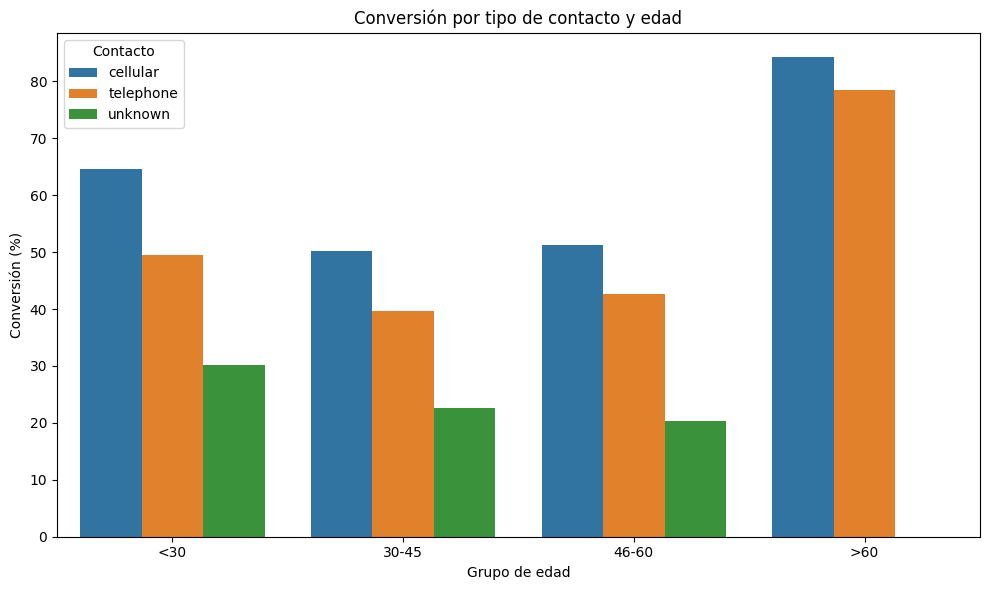

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=conversion_age,
    x="age_group",
    y="conversion_rate",
    hue="contact"
)

plt.title("Conversión por tipo de contacto y edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Conversión (%)")
plt.legend(title="Contacto")
plt.tight_layout()
plt.show()

---

## **Recomendaciones**

A partir de los resultados obtenidos, se recomienda priorizar el canal móvil en los primeros intentos de contacto, ya que presenta una mayor tasa de conversión inicial. Sin embargo, dado el efecto de saturación observado, se sugiere limitar el número de intentos y combinar estrategias con otros canales en fases posteriores. Además, sería recomendable analizar con mayor profundidad la categoría 'unknown' para reducir su impacto y mejorar la calidad del targeting.